## 1. Cycle Life Distribution

In [1]:
import os
import glob
import scipy.io
import mat73
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 아카이브 폴더 경로 지정
DATA_DIR = '/Users/seunghyunsuh/Downloads/archive'
mat_files = sorted(glob.glob(os.path.join(DATA_DIR, '*batchdata*.mat')))

mats = {}
for path in mat_files:
    filename = os.path.basename(path)
    print(f"로딩 중... ({filename})")
    try:
        data = mat73.loadmat(path)
    except Exception:
        data = scipy.io.loadmat(path, simplify_cells=True)
    mats[filename] = data

# 2. 세 배치를 하나의 통합 DataFrame으로 병합 (None 타입 방어 코드 적용)
all_dfs = []
for filename, mat_data in mats.items():
    batch_name = filename.split('_')[0]
    main_key = 'batch' if 'batch' in mat_data else [k for k in mat_data.keys() if not k.startswith('__')][0]
    batch_struct = mat_data[main_key]
    
    cycles = batch_struct['cycles']
    policies = batch_struct['policy']
    
    for idx, cell in enumerate(cycles):
        v = cell.get('V') if isinstance(cell, dict) else cell['V']
        if v is None:
            continue
            
        qd = cell.get('Qd') if isinstance(cell, dict) else cell.get('QD')
        qc = cell.get('Qc') if isinstance(cell, dict) else cell.get('QC')
        t = cell.get('T') if isinstance(cell, dict) else cell.get('t')
        ir = cell.get('IR') if isinstance(cell, dict) else cell.get('ir')
        ct = cell.get('chargetime') if isinstance(cell, dict) else cell.get('CT')
        
        life = len(v)
        
        def safe_val(arr, c_idx, is_mean=True):
            if arr is None or c_idx >= len(arr):
                return 0.0
            val = arr[c_idx]
            if val is None:
                return 0.0
            try:
                if is_mean and hasattr(val, '__len__') and not isinstance(val, (str, bytes)) and len(val) > 0:
                    return float(np.mean(val))
                return float(val)
            except Exception:
                return 0.0

        for c in range(life):
            all_dfs.append({
                'cell_id': f"{batch_name}_cell_{idx}",
                'batch': batch_name,
                'cycle': c + 1,
                'cycle_life': life,
                'charging_policy': str(policies[idx]) if policies is not None else 'Unknown',
                'QD': safe_val(qd, c, True),
                'QC': safe_val(qc, c, True),
                'IR': safe_val(ir, c, False),
                'Tavg': safe_val(t, c, True),
                'Tmax': float(np.max(t[c])) if t is not None and c < len(t) and t[c] is not None and hasattr(t[c], '__len__') and len(t[c]) > 0 else 0.0,
                'chargetime': safe_val(ct, c, False)
            })

df = pd.DataFrame(all_dfs)
print(f"\n[통합 완료] 총 데이터 행 수: {len(df)}, 총 셀 개수: {df['cell_id'].nunique()}")
print("포함된 배치 목록:", df['batch'].unique())

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (2017-05-12_batchdata_updated_struct_errorcorrect.mat)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (2018-02-20_batchdata_updated_struct_errorcorrect.mat)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


로딩 중... (2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (2018-04-12_batchdata_updated_struct_errorcorrect.mat)

[통합 완료] 총 데이터 행 수: 117775, 총 셀 개수: 141
포함된 배치 목록: <StringArray>
['2017-05-12', '2018-02-20', '2018-04-03', '2018-04-12']
Length: 4, dtype: str


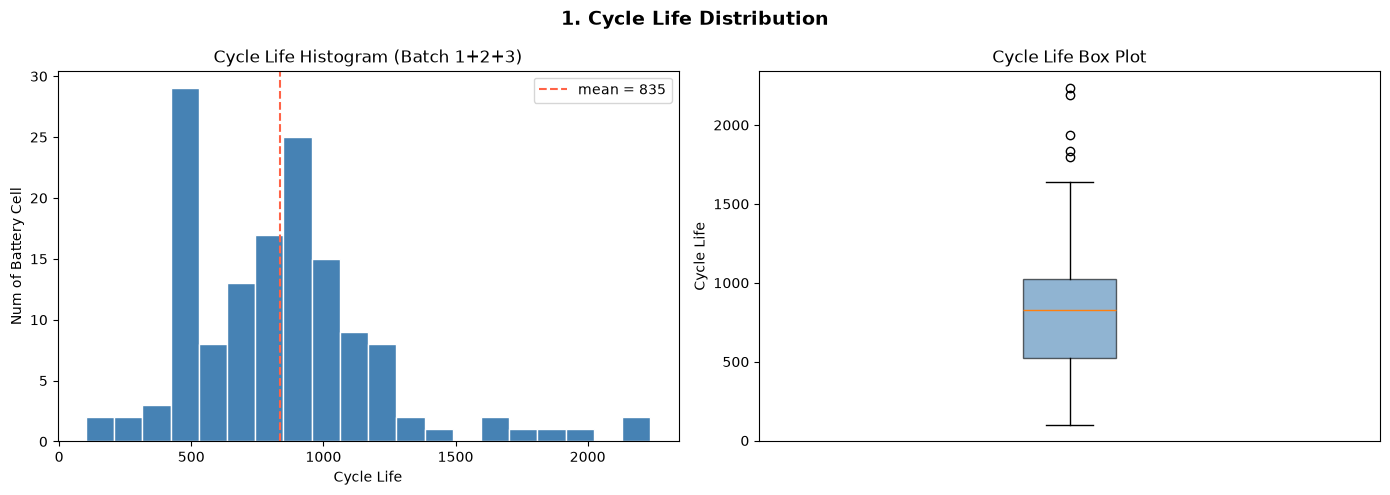


[Cycle Life 요약 통계]
count     141.0
mean      835.3
std       362.9
min       101.0
25%       523.0
50%       827.0
75%      1027.0
max      2237.0
Name: cycle_life, dtype: float64


In [2]:
cycle_life_df = (
    df.drop_duplicates('cell_id')
      [['cell_id', 'batch', 'cycle_life', 'charging_policy']]
      .copy()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Cycle Life Histogram (Batch 1+2+3)')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('Num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Cycle Life Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('1. Cycle Life Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[Cycle Life 요약 통계]")
print(cycle_life_df['cycle_life'].describe().round(1))

In [3]:
print(cycle_life_df.columns.tolist())
print(cycle_life_df.shape)

['cell_id', 'batch', 'cycle_life', 'charging_policy']
(141, 4)


In [4]:

# Batch별 Cycle Life 요약 통계
batch_stats = cycle_life_df.groupby('batch')['cycle_life'].agg(
    cell_count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
)

batch_stats['short_life_ratio'] = (
    cycle_life_df.assign(short=cycle_life_df['cycle_life'] < 500)
    .groupby('batch')['short'].mean() * 100
)

batch_stats['long_life_ratio'] = (
    cycle_life_df.assign(long=cycle_life_df['cycle_life'] > 1000)
    .groupby('batch')['long'].mean() * 100
)

print("[Batch별 Cycle Life 비교]")
print(batch_stats.round(2))

[Batch별 Cycle Life 비교]
            cell_count     mean  median     std  min   max  short_life_ratio  \
batch                                                                          
2017-05-12          46   843.72   857.5  184.63  533  1226               0.0   
2018-02-20          47   572.43   493.0  258.39  101  1252              61.7   
2018-04-03           2   526.50   526.5  405.17  240   813              50.0   
2018-04-12          46  1108.85  1017.5  388.34  540  2237               0.0   

            long_life_ratio  
batch                        
2017-05-12            21.74  
2018-02-20            10.64  
2018-04-03             0.00  
2018-04-12            54.35  


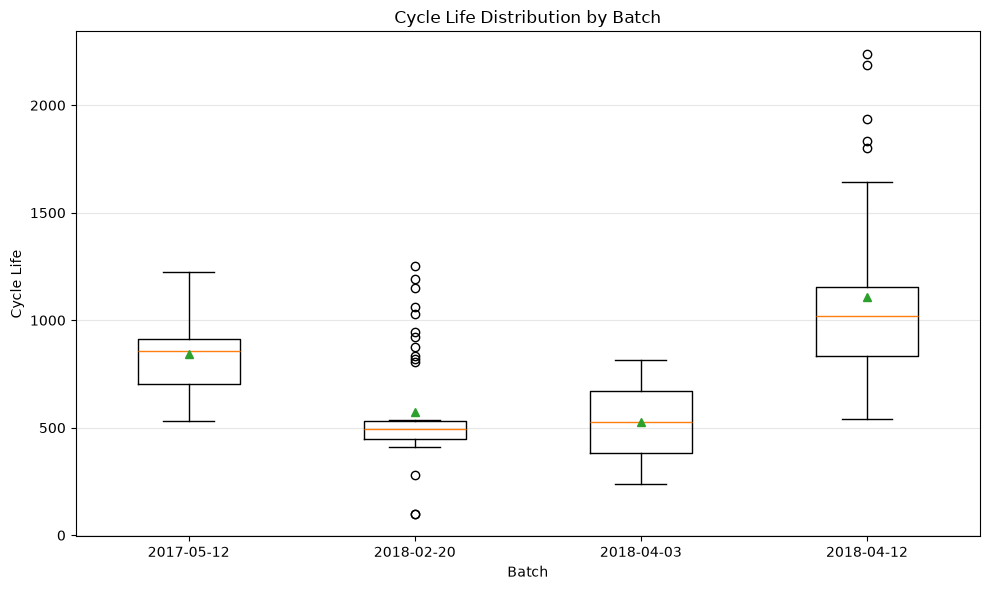

=== Batch별 Cycle Life 통계 ===


,n,mean,median,std,min,max,short_life_ratio(%),long_life_ratio(%)
batch,,,,,,,,
2017-05-12,46,843.72,857.5,184.63,533,1226,0.0,21.74
2018-02-20,47,572.43,493.0,258.39,101,1252,61.7,10.64
2018-04-03,2,526.50,526.5,405.17,240,813,50.0,0.00
2018-04-12,46,1108.85,1017.5,388.34,540,2237,0.0,54.35


In [5]:
# ============================================================
# 1-1. Batch별 Cycle Life 분포 비교
# ============================================================
# Batch 순서
batch_order = sorted(cycle_life_df['batch'].unique())

# Batch별 데이터
batch_data = [
    cycle_life_df.loc[
        cycle_life_df['batch'] == batch,
        'cycle_life'
    ].values
    for batch in batch_order
]

# Batch 순서
batch_order = sorted(cycle_life_df['batch'].unique())

# Batch별 데이터
batch_data = [
    cycle_life_df.loc[
        cycle_life_df['batch'] == batch,
        'cycle_life'
    ].values
    for batch in batch_order
]

# ------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.boxplot(
    batch_data,
    tick_labels=batch_order,
    showmeans=True
)

plt.xlabel('Batch')
plt.ylabel('Cycle Life')
plt.title('Cycle Life Distribution by Batch')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Batch별 통계값 출력
# ------------------------------------------------------------

batch_summary = (
    cycle_life_df
    .groupby('batch')['cycle_life']
    .agg(
        n='count',
        mean='mean',
        median='median',
        std='std',
        min='min',
        max='max'
    )
)

# Short / Long 비율
short_ratio = (
    cycle_life_df
    .assign(short=cycle_life_df['cycle_life'] < 500)
    .groupby('batch')['short']
    .mean() * 100
)

long_ratio = (
    cycle_life_df
    .assign(long=cycle_life_df['cycle_life'] > 1000)
    .groupby('batch')['long']
    .mean() * 100
)

batch_summary['short_life_ratio(%)'] = short_ratio
batch_summary['long_life_ratio(%)'] = long_ratio

print("=== Batch별 Cycle Life 통계 ===")
display(batch_summary.round(2))

In [6]:
print(cycle_life_df.columns.tolist())
print(cycle_life_df.shape)

['cell_id', 'batch', 'cycle_life', 'charging_policy']
(141, 4)


## 2. Degradation Curve

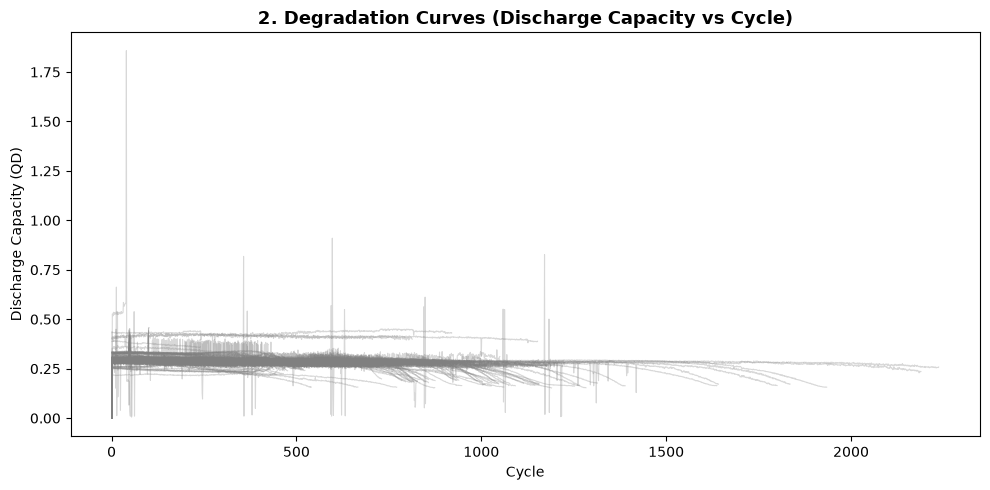

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for cell_id, group in df.groupby('cell_id'):
    ax.plot(group['cycle'], group['QD'], color='gray', alpha=0.3, linewidth=0.8)

ax.set_title('2. Degradation Curves (Discharge Capacity vs Cycle)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cycle')
ax.set_ylabel('Discharge Capacity (QD)')
plt.tight_layout()
plt.show()

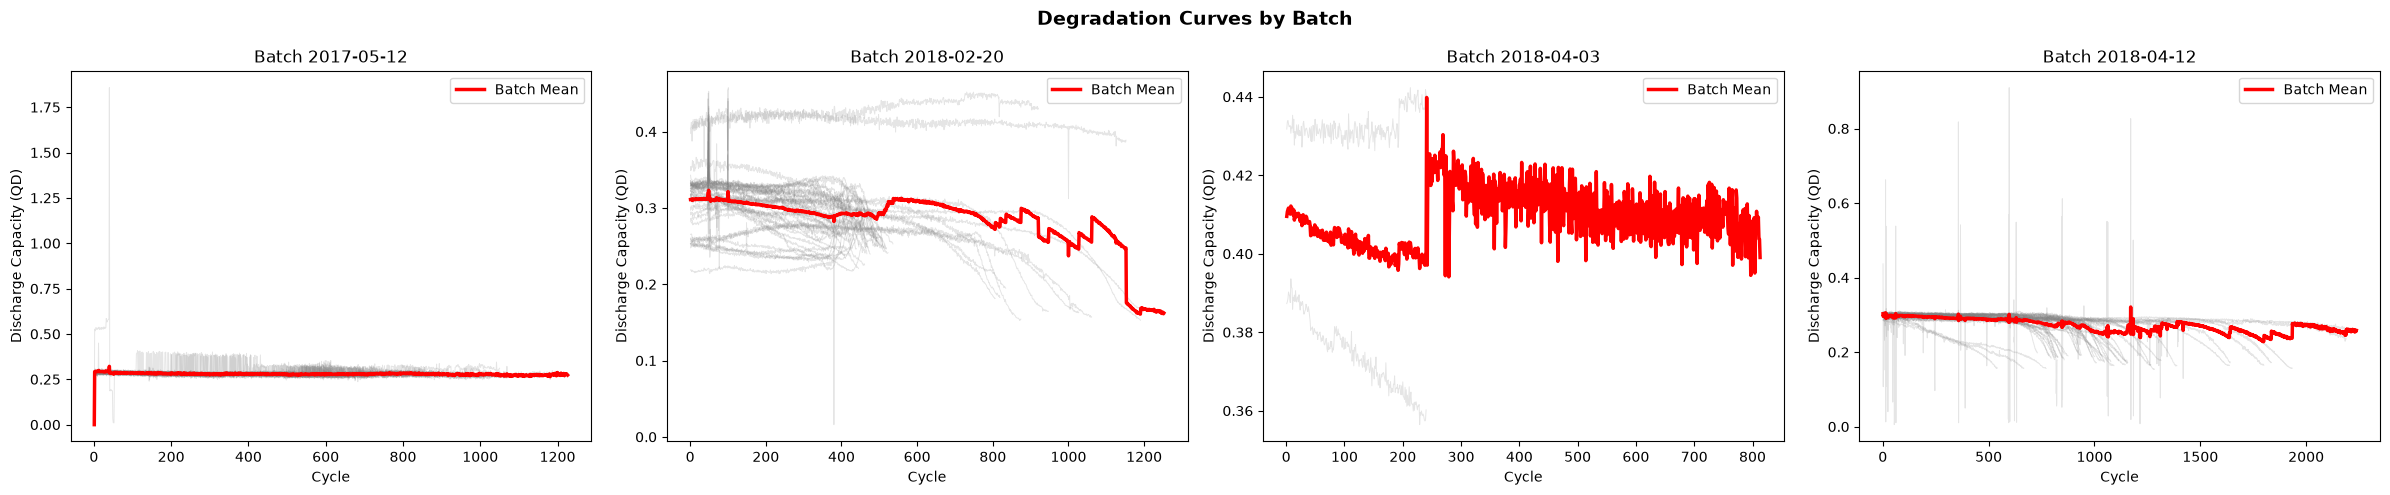

In [ ]:

# 2. Batch별 Degradation Curve 비교

batches = sorted(df['batch'].dropna().unique())

fig, axes = plt.subplots(1, len(batches), figsize=(6 * len(batches), 5))
if len(batches) == 1:
    axes = [axes]

for ax, batch in zip(axes, batches):
    batch_df = df[df['batch'] == batch]

    # 개별 셀의 열화 곡선
    for cell_id, group in batch_df.groupby('cell_id'):
        ax.plot(group['cycle'], group['QD'],
                color='gray', alpha=0.2, linewidth=0.7)

    # Batch별 사이클 평균 방전 용량
    mean_curve = batch_df.groupby('cycle')['QD'].mean()

    ax.plot(mean_curve.index, mean_curve.values,
            color='red', linewidth=2.5, label='Batch Mean')

    ax.set_title(f'Batch {batch}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Discharge Capacity (QD)')
    ax.legend()

plt.suptitle('Degradation Curves by Batch',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. ΔQ(V) Analysis

In [ ]:
# ============================================================
# 3. ΔQ(V) 분석
# Cycle 100 - Cycle 10
# Qdlin 사용
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


delta_qv_results = []

for filename, mat_data in mats.items():

    batch_name = filename.split('_')[0]

    main_key = (
        'batch'
        if 'batch' in mat_data
        else [
            k for k in mat_data.keys()
            if not k.startswith('__')
        ][0]
    )

    cells = mat_data[main_key]['cycles']

    for idx, cell in enumerate(cells):

        Qdlin = cell.get('Qdlin')

        # Qdlin이 없거나 Cycle 100까지 없으면 제외
        if Qdlin is None or len(Qdlin) < 100:
            continue

        # Cycle 10 / Cycle 100
        Q10 = np.asarray(
            Qdlin[9],
            dtype=float
        ).flatten()

        Q100 = np.asarray(
            Qdlin[99],
            dtype=float
        ).flatten()

        # NaN 제거 및 길이 확인
        n = min(len(Q10), len(Q100))

        Q10 = Q10[:n]
        Q100 = Q100[:n]

        valid = (
            np.isfinite(Q10) &
            np.isfinite(Q100)
        )

        Q10 = Q10[valid]
        Q100 = Q100[valid]

        if len(Q10) < 10:
            continue

        # ΔQ(V)
        delta_Q = Q100 - Q10

        cell_id = f"{batch_name}_cell_{idx}"

        life_row = df[
            df['cell_id'] == cell_id
        ]

        if len(life_row) == 0:
            continue

        cycle_life = life_row[
            'cycle_life'
        ].iloc[0]

        delta_qv_results.append({

            'cell_id': cell_id,
            'batch': batch_name,
            'cycle_life': cycle_life,

            # 곡선 저장
            'delta_Q': delta_Q,

            # 통계 feature
            'deltaQ_mean': np.mean(delta_Q),
            'deltaQ_std': np.std(delta_Q),
            'deltaQ_var': np.var(delta_Q),
            'deltaQ_min': np.min(delta_Q),
            'deltaQ_max': np.max(delta_Q),
            'deltaQ_range':
                np.max(delta_Q) - np.min(delta_Q)
        })


delta_qv_df = pd.DataFrame(
    delta_qv_results
)


print("ΔQ(V) 계산 완료")
print(
    "사용된 Cell 수:",
    len(delta_qv_df)
)

print("\nFeature Summary")

display(
    delta_qv_df[
        [
            'cycle_life',
            'deltaQ_mean',
            'deltaQ_std',
            'deltaQ_var',
            'deltaQ_min',
            'deltaQ_max',
            'deltaQ_range'
        ]
    ].describe().round(5)
)

ΔQ(V) 계산 완료
사용된 Cell 수: 141

Feature Summary


,cycle_life,deltaQ_mean,deltaQ_std,deltaQ_var,deltaQ_min,deltaQ_max,deltaQ_range
count,141.00000,141.00000,141.00000,141.00000,141.00000,141.00000,141.00000
mean,835.28369,-0.01742,0.01241,0.00020,-0.03737,0.00104,0.03841
std,362.92076,0.01162,0.00665,0.00024,0.02004,0.00343,0.01898
min,101.00000,-0.08443,0.00158,0.00000,-0.13603,-0.00021,0.00923
25%,523.00000,-0.02414,0.00766,0.00006,-0.05256,-0.00006,0.02530
50%,827.00000,-0.01334,0.00999,0.00010,-0.02995,0.00002,0.02985
75%,1027.00000,-0.01011,0.01745,0.00030,-0.02408,0.00014,0.05248
max,2237.00000,0.00078,0.04545,0.00207,-0.00531,0.02170,0.13603


Life Group별 Cell 수
life_group
Middle               71
Long-life (>1000)    40
Short-life (<500)    30
Name: count, dtype: int64

ΔQ curve length
delta_Q
1000    141
Name: count, dtype: int64


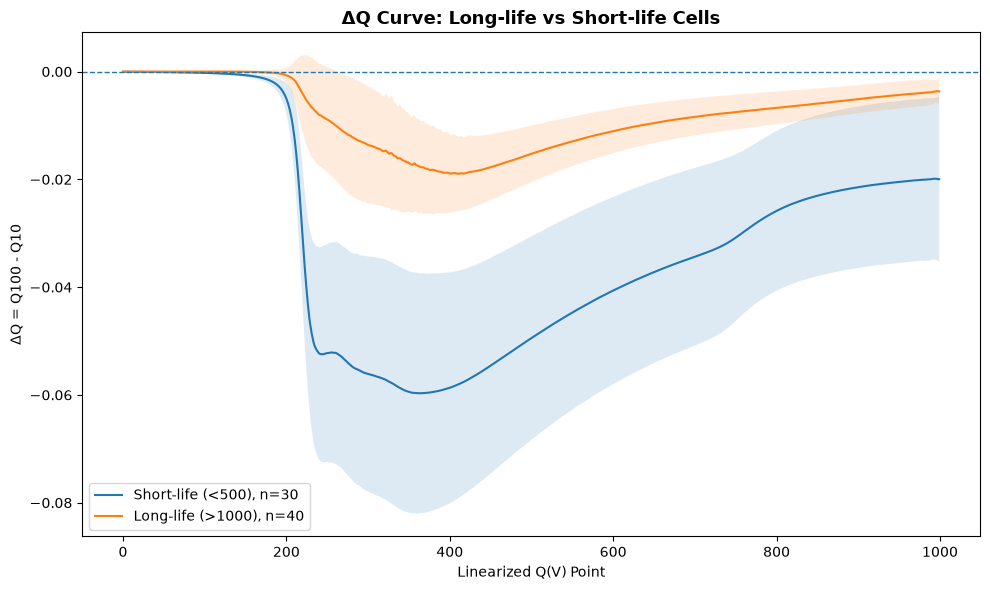

In [ ]:
# ============================================================
# 3-1. Long-life vs Short-life ΔQ 비교
# ============================================================

# 수명 그룹 구분
delta_qv_df['life_group'] = np.where(
    delta_qv_df['cycle_life'] < 500,
    'Short-life (<500)',
    np.where(
        delta_qv_df['cycle_life'] > 1000,
        'Long-life (>1000)',
        'Middle'
    )
)

# 그룹별 셀 개수
print("Life Group별 Cell 수")
print(delta_qv_df['life_group'].value_counts())

# Short / Long만 선택
short_df = delta_qv_df[
    delta_qv_df['life_group'] == 'Short-life (<500)'
]

long_df = delta_qv_df[
    delta_qv_df['life_group'] == 'Long-life (>1000)'
]


# 모든 ΔQ curve 길이 확인
print("\nΔQ curve length")
print(
    delta_qv_df['delta_Q']
    .apply(len)
    .value_counts()
    .head()
)


# ------------------------------------------------------------
# 같은 길이의 curve만 사용해서 평균 계산
# ------------------------------------------------------------

common_length = (
    delta_qv_df['delta_Q']
    .apply(len)
    .mode()[0]
)

short_curves = np.array([
    x for x in short_df['delta_Q']
    if len(x) == common_length
])

long_curves = np.array([
    x for x in long_df['delta_Q']
    if len(x) == common_length
])


short_mean = short_curves.mean(axis=0)
short_std = short_curves.std(axis=0)

long_mean = long_curves.mean(axis=0)
long_std = long_curves.std(axis=0)


# ------------------------------------------------------------
# 그래프
# 아직 정확한 Voltage grid를 확정하지 않았으므로
# x축은 Linearized Q(V) Point로 표시
# ------------------------------------------------------------

x = np.arange(common_length)

fig, ax = plt.subplots(figsize=(10, 6))


# Short-life
ax.plot(
    x,
    short_mean,
    label=f'Short-life (<500), n={len(short_curves)}'
)

ax.fill_between(
    x,
    short_mean - short_std,
    short_mean + short_std,
    alpha=0.15
)


# Long-life
ax.plot(
    x,
    long_mean,
    label=f'Long-life (>1000), n={len(long_curves)}'
)

ax.fill_between(
    x,
    long_mean - long_std,
    long_mean + long_std,
    alpha=0.15
)


ax.axhline(
    0,
    linestyle='--',
    linewidth=1
)

ax.set_xlabel('Linearized Q(V) Point')
ax.set_ylabel('ΔQ = Q100 - Q10')

ax.set_title(
    'ΔQ Curve: Long-life vs Short-life Cells',
    fontsize=13,
    fontweight='bold'
)

ax.legend()

plt.tight_layout()
plt.show()


=== Short-life vs Long-life Feature 평균 ===


deltaQ_mean                   deltaQ_std                    \
                         mean   median      std       mean   median      std   
life_group                                                                     
Long-life (>1000)    -0.00829 -0.00851  0.00369    0.00677  0.00684  0.00195   
Short-life (<500)    -0.03146 -0.02998  0.01378    0.02053  0.01902  0.00710   

                  deltaQ_var                   deltaQ_min                    \
                        mean   median      std       mean   median      std   
life_group                                                                    
Long-life (>1000)    0.00005  0.00005  0.00003   -0.01994 -0.01955  0.00673   
Short-life (<500)    0.00047  0.00036  0.00036   -0.06208 -0.05578  0.01981   

                  deltaQ_max                   deltaQ_range                    
                        mean   median      std         mean   median      std  
life_group                                                                     
Long-life (>1000)    0.00289  0.00008  0.00537      0.02284  0.02325  0.00518  
Short-life (<500)   -0.00001 -0.00003  0.00013      0.06207  0.05572  0.01983


=== ΔQ Feature와 Cycle Life의 Correlation ===


deltaQ_min      0.726
deltaQ_std     -0.696
deltaQ_range   -0.688
deltaQ_mean     0.670
deltaQ_var     -0.567
deltaQ_max      0.436
Name: cycle_life, dtype: float64

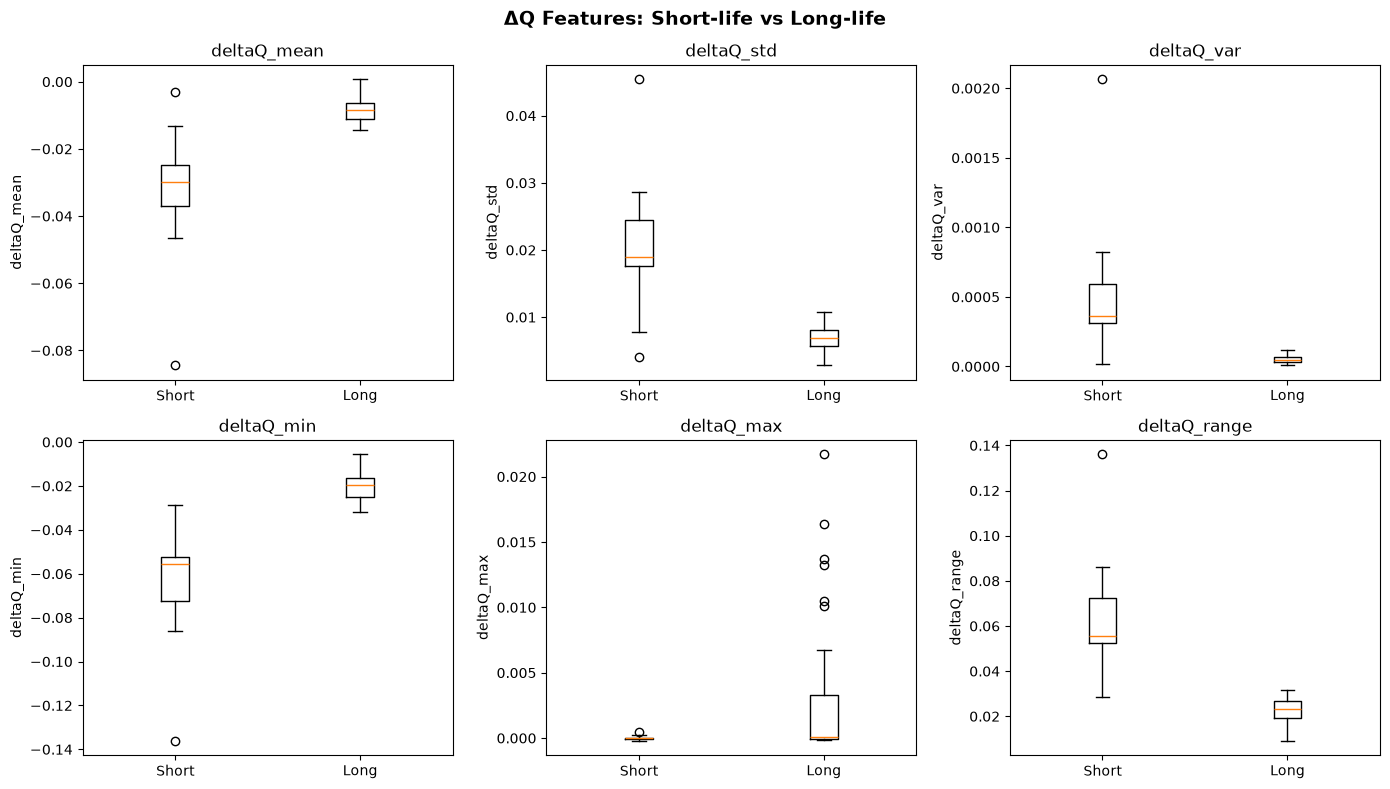

In [ ]:
# ============================================================
# 3-2. ΔQ 통계 Feature 비교
# ============================================================

features = [
    'deltaQ_mean',
    'deltaQ_std',
    'deltaQ_var',
    'deltaQ_min',
    'deltaQ_max',
    'deltaQ_range'
]

# Short / Long만 사용
compare_df = delta_qv_df[
    delta_qv_df['life_group'].isin([
        'Short-life (<500)',
        'Long-life (>1000)'
    ])
].copy()


# 1. 그룹별 평균
print("=== Short-life vs Long-life Feature 평균 ===")

feature_summary = (
    compare_df
    .groupby('life_group')[features]
    .agg(['mean', 'median', 'std'])
    .round(5)
)

display(feature_summary)


# 2. Cycle Life와 각 Feature의 Pearson correlation
print("\n=== ΔQ Feature와 Cycle Life의 Correlation ===")

corr = (
    delta_qv_df[
        ['cycle_life'] + features
    ]
    .corr()['cycle_life']
    .drop('cycle_life')
    .sort_values(key=abs, ascending=False)
)

display(corr.round(3))


# 3. Short vs Long Boxplot
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8)
)

axes = axes.flatten()

groups = [
    'Short-life (<500)',
    'Long-life (>1000)'
]

for i, feature in enumerate(features):

    data = [
        compare_df.loc[
            compare_df['life_group'] == group,
            feature
        ].dropna()
        for group in groups
    ]

    axes[i].boxplot(
        data,
        tick_labels=['Short', 'Long']
    )

    axes[i].set_title(feature)
    axes[i].set_ylabel(feature)

plt.suptitle(
    'ΔQ Features: Short-life vs Long-life',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## 4. Charging Policy Analysis

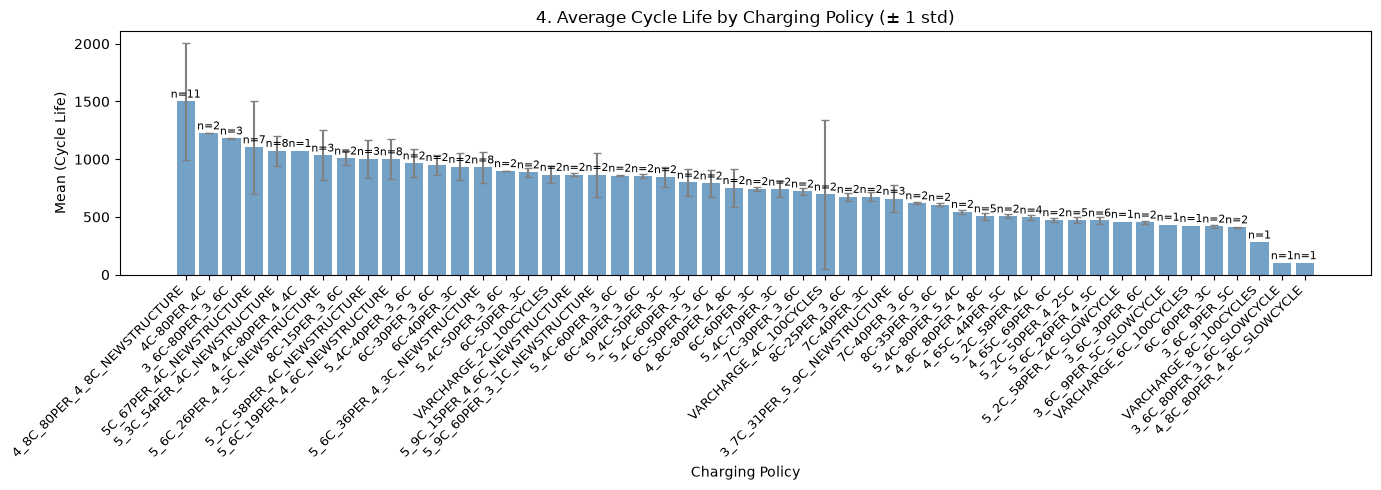

In [7]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count']).reset_index()
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life['charging_policy'], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('Mean (Cycle Life)')
ax.set_title('4. Average Cycle Life by Charging Policy (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[Charging Policy x Batch 요약]
             charging_policy      batch    mean    std  count
             3_6C-80PER_3_6C 2017-05-12 1181.00   7.00      3
               3_6C_30PER_6C 2018-02-20  453.00  11.31      2
   3_6C_80PER_3_6C_SLOWCYCLE 2018-02-20  101.00    NaN      1
                3_6C_9PER_5C 2018-02-20  411.50   3.54      2
      3_6C_9PER_5C_SLOWCYCLE 2018-02-20  434.00    NaN      1
3_7C_31PER_5_9C_NEWSTRUCTURE 2018-04-12  659.00 115.66      3
                 4C-80PER_4C 2017-05-12 1225.50   0.71      2
             4_4C-80PER_4_4C 2017-05-12 1073.00    NaN      1
              4_65C_44PER_5C 2018-02-20  505.00  16.97      2
              4_65C_69PER_6C 2018-02-20  473.50  13.44      2
             4_8C-80PER_4_8C 2017-05-12  752.00 165.46      2
             4_8C_80PER_4_8C 2018-02-20  506.60  31.25      5
4_8C_80PER_4_8C_NEWSTRUCTURE 2018-02-20  900.33 139.84      3
4_8C_80PER_4_8C_NEWSTRUCTURE 2018-04-12 1725.62 385.96      8
   4_8C_80PER_4_8C_SLOWCYCLE 2018-02-20  

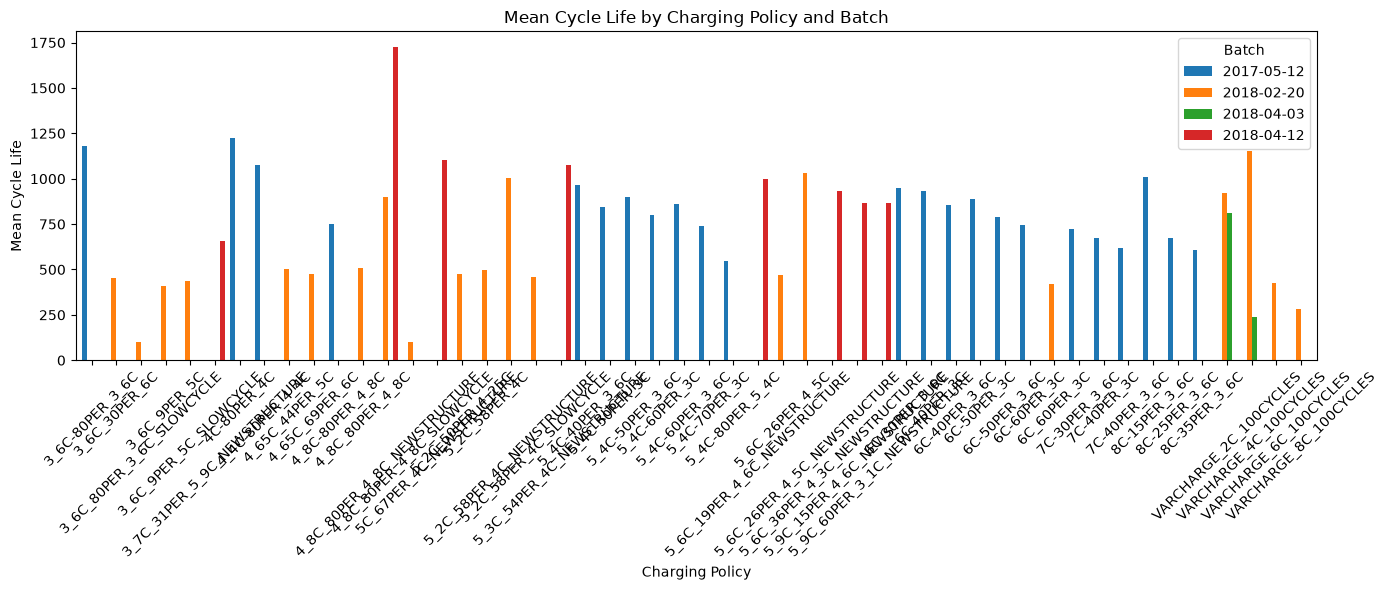

In [ ]:

# 4. Batch별 Charging Policy와 Cycle Life 비교

policy_batch = cycle_life_df.groupby(
    ['charging_policy', 'batch']
)['cycle_life'].agg(
    mean='mean',
    std='std',
    count='count'
).reset_index()

print("[Charging Policy x Batch 요약]")
print(policy_batch.round(2).to_string(index=False))

# Batch별 평균 Cycle Life 비교 그래프
mean_pivot = policy_batch.pivot(
    index='charging_policy',
    columns='batch',
    values='mean'
)

ax = mean_pivot.plot(
    kind='bar',
    figsize=(14, 6),
    width=0.8
)

ax.set_title('Mean Cycle Life by Charging Policy and Batch')
ax.set_xlabel('Charging Policy')
ax.set_ylabel('Mean Cycle Life')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Batch')
plt.tight_layout()
plt.show()

## 5. Early-cycle Feature Correlation

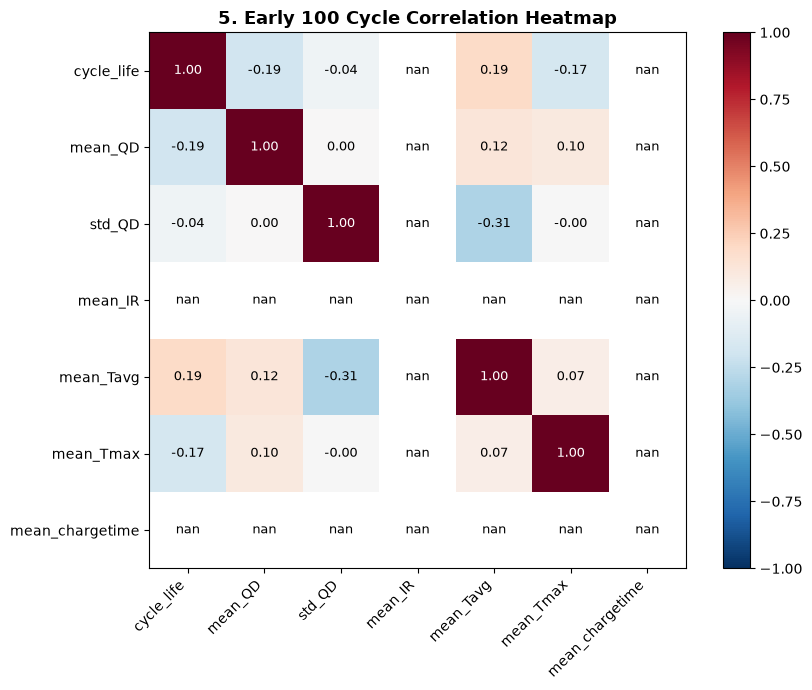


[cycle_life Correlation Rank]
mean_Tavg          0.194
mean_QD           -0.193
mean_Tmax         -0.172
std_QD            -0.042
mean_IR              NaN
mean_chargetime      NaN
Name: cycle_life, dtype: float64


In [8]:
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life      = ('cycle_life', 'first'),
    mean_QD         = ('QD', 'mean'),
    std_QD          = ('QD', 'std'),
    mean_IR         = ('IR', 'mean'),
    mean_Tavg       = ('Tavg', 'mean'),
    mean_Tmax       = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)

ax.set_title('5. Early 100 Cycle Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Correlation Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))


[Batch 2017-05-12 Correlation with Cycle Life]
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD           -0.242
std_QD            -0.124
mean_IR              NaN
mean_chargetime      NaN
Name: cycle_life, dtype: float64

[Batch 2018-02-20 Correlation with Cycle Life]
std_QD            -0.313
mean_Tmax         -0.276
mean_Tavg          0.181
mean_QD            0.020
mean_IR              NaN
mean_chargetime      NaN
Name: cycle_life, dtype: float64

[Batch 2018-04-03 Correlation with Cycle Life]
mean_QD            1.0
std_QD            -1.0
mean_Tavg          1.0
mean_Tmax          1.0
mean_IR            NaN
mean_chargetime    NaN
Name: cycle_life, dtype: float64

[Batch 2018-04-12 Correlation with Cycle Life]
mean_QD           -0.303
std_QD             0.103
mean_Tavg          0.084
mean_Tmax          0.002
mean_IR              NaN
mean_chargetime      NaN
Name: cycle_life, dtype: float64


/var/folders/61/20fn7v5j63l8md1yk_lf42tw0000gn/T/ipykernel_16080/3169165737.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


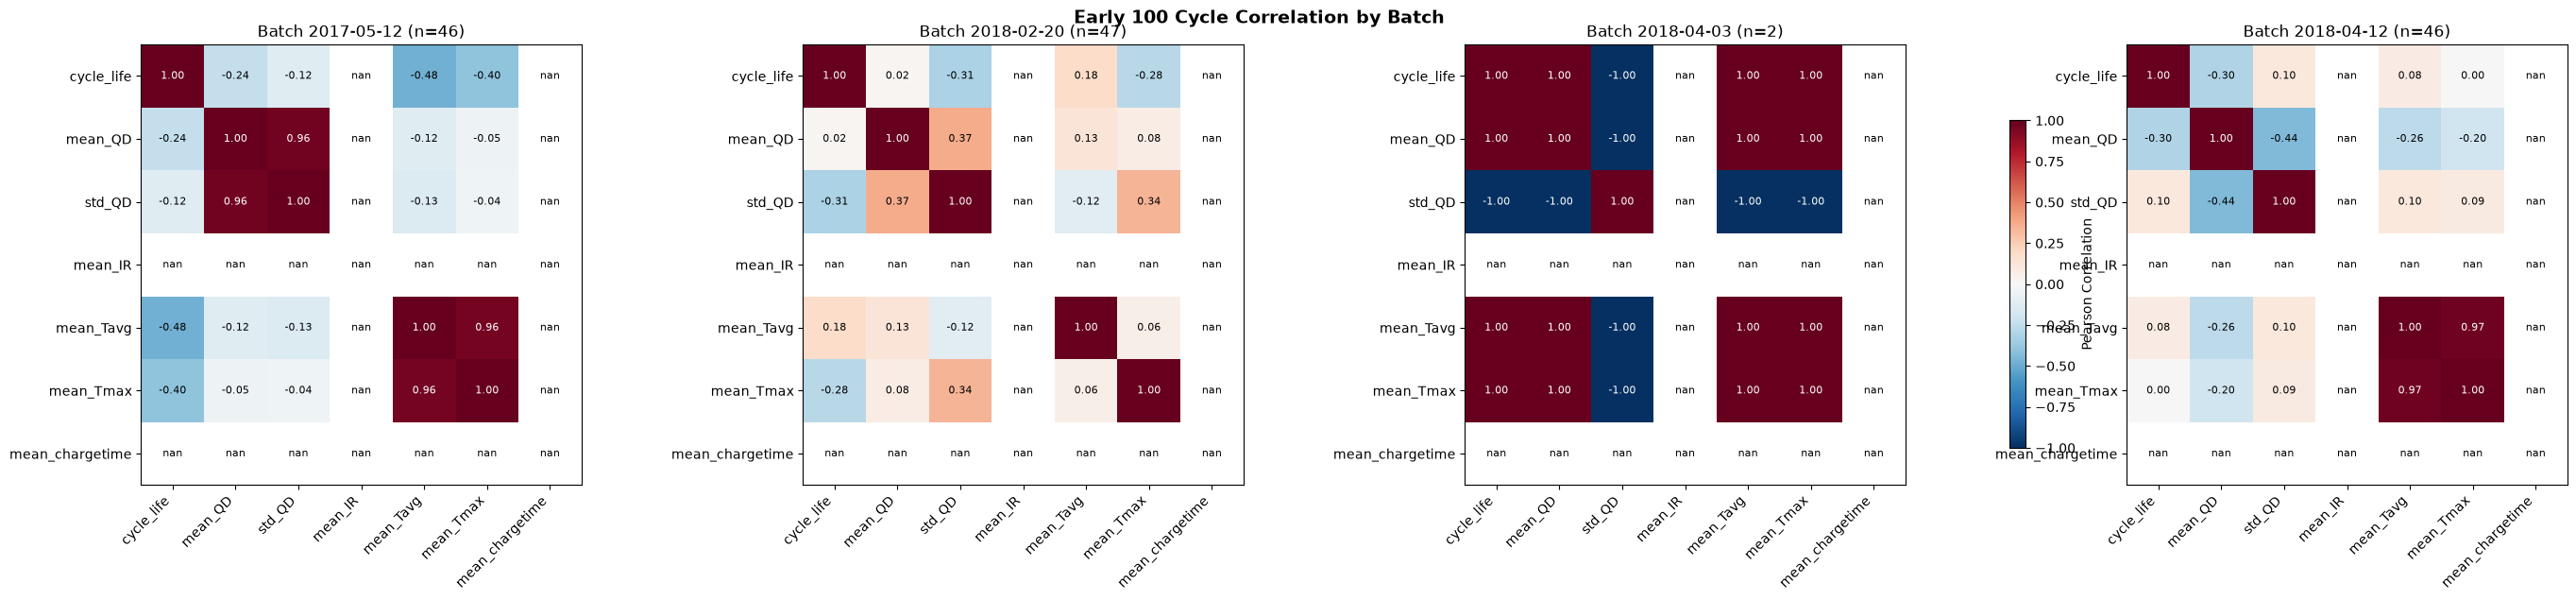

In [9]:

# 5. Batch별 초기 100 Cycle Feature 상관관계 비교

early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life      = ('cycle_life', 'first'),
    batch           = ('batch', 'first'),
    mean_QD         = ('QD', 'mean'),
    std_QD          = ('QD', 'std'),
    mean_IR         = ('IR', 'mean'),
    mean_Tavg       = ('Tavg', 'mean'),
    mean_Tmax       = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean')
).reset_index()

features = [
    'cycle_life', 'mean_QD', 'std_QD',
    'mean_IR', 'mean_Tavg', 'mean_Tmax',
    'mean_chargetime'
]

batches = sorted(early['batch'].dropna().unique())

fig, axes = plt.subplots(
    1, len(batches),
    figsize=(7 * len(batches), 6)
)

if len(batches) == 1:
    axes = [axes]

for ax, batch in zip(axes, batches):
    batch_early = early[early['batch'] == batch]
    corr = batch_early[features].corr()

    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

    ax.set_xticks(range(len(features)))
    ax.set_yticks(range(len(features)))
    ax.set_xticklabels(features, rotation=45, ha='right')
    ax.set_yticklabels(features)

    for i in range(len(features)):
        for j in range(len(features)):
            val = corr.iloc[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}',
                    ha='center', va='center',
                    fontsize=8, color=color)

    ax.set_title(f'Batch {batch} (n={len(batch_early)})')

    print(f'\n[Batch {batch} Correlation with Cycle Life]')
    print(
        corr['cycle_life']
        .drop('cycle_life')
        .sort_values(key=abs, ascending=False)
        .round(3)
    )

fig.colorbar(im, ax=axes, shrink=0.75, label='Pearson Correlation')
plt.suptitle('Early 100 Cycle Correlation by Batch',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()